1) Imports + Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = "results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Model parameters (same as Day 4)
L = 32
H = 32
Dh = 128
d = H * Dh

# Hardware
PEAK_FLOPS = 312e12
PEAK_BW = 1.6e12

# Energy constants
E_BYTE_HBM = 5e-12
E_FLOP = 1e-12

# Precision
FP16 = 2
INT8 = 1
INT4 = 0.5

T_vals = np.array([128,256,512,1024,2048])

2) Baseline Functions

In [2]:
def bytes_attention_per_token(T, kv_bytes):
    kv_read = 2 * L * H * Dh * T * kv_bytes
    kv_write = 2 * L * H * Dh * kv_bytes
    return kv_read + kv_write

def bytes_ffn_per_token(weight_bytes=2, alpha=8):
    return L * alpha * d * d * weight_bytes

def flops_attention_per_token(T):
    return 4 * L * H * T * Dh

def flops_ffn_per_token(alpha=8):
    return alpha * L * d * d

def flops_total_per_token(T):
    return flops_attention_per_token(T) + flops_ffn_per_token()

def energy_per_token(T, kv_bytes):
    total_bytes = bytes_attention_per_token(T, kv_bytes) + bytes_ffn_per_token()
    return total_bytes * E_BYTE_HBM

def latency_per_token(T, kv_bytes):
    total_bytes = bytes_attention_per_token(T, kv_bytes) + bytes_ffn_per_token()
    total_flops = flops_total_per_token(T)
    t_mem = total_bytes / PEAK_BW
    t_comp = total_flops / PEAK_FLOPS
    return max(t_mem, t_comp)

3) KV Quantization Modeling

In [3]:
E_fp16 = [energy_per_token(T, FP16) for T in T_vals]
E_int8 = [energy_per_token(T, INT8) for T in T_vals]
E_int4 = [energy_per_token(T, INT4) for T in T_vals]

4) PagedAttention Model

In [4]:
def energy_paged(T, kv_bytes, gamma=0.7):
    kv_read = 2 * L * H * Dh * T * kv_bytes * gamma
    kv_write = 2 * L * H * Dh * kv_bytes
    ffn_bytes = bytes_ffn_per_token()
    return (kv_read + kv_write + ffn_bytes) * E_BYTE_HBM
E_paged = [energy_paged(T, FP16, gamma=0.7) for T in T_vals]

5) FlashAttention Model

In [5]:
def energy_flash(T, kv_bytes, beta=0.6):
    attn_bytes = bytes_attention_per_token(T, kv_bytes) * beta
    ffn_bytes = bytes_ffn_per_token()
    return (attn_bytes + ffn_bytes) * E_BYTE_HBM
E_flash = [energy_flash(T, FP16, beta=0.6) for T in T_vals]

6) Energy Comparison Plot (MAIN RESULT)

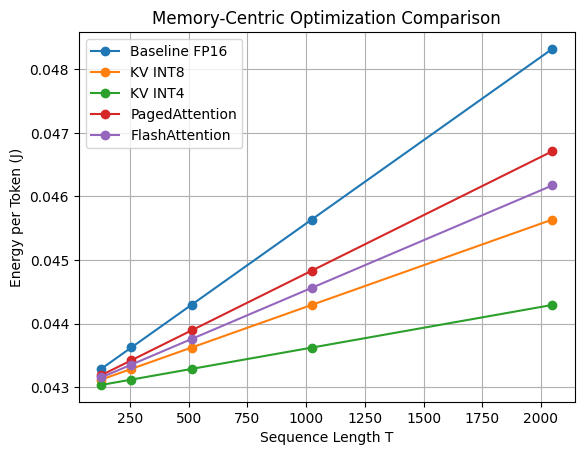

In [6]:
plt.figure()
plt.plot(T_vals, E_fp16, marker='o')
plt.plot(T_vals, E_int8, marker='o')
plt.plot(T_vals, E_int4, marker='o')
plt.plot(T_vals, E_paged, marker='o')
plt.plot(T_vals, E_flash, marker='o')

plt.xlabel("Sequence Length T")
plt.ylabel("Energy per Token (J)")
plt.title("Memory-Centric Optimization Comparison")
plt.legend(["Baseline FP16","KV INT8","KV INT4","PagedAttention","FlashAttention"])
plt.grid(True)

plt.savefig(os.path.join(FIG_DIR,"memory_optimizations_energy.png"), dpi=200)
plt.show()

7) Latency Comparison Plot

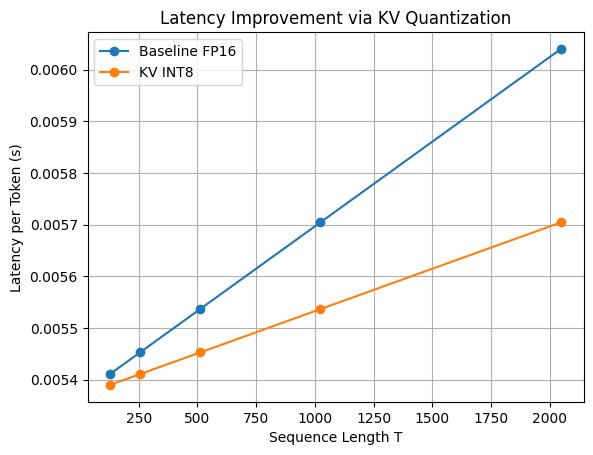

In [7]:
L_fp16 = [latency_per_token(T, FP16) for T in T_vals]
L_int8 = [latency_per_token(T, INT8) for T in T_vals]

plt.figure()
plt.plot(T_vals, L_fp16, marker='o')
plt.plot(T_vals, L_int8, marker='o')

plt.xlabel("Sequence Length T")
plt.ylabel("Latency per Token (s)")
plt.title("Latency Improvement via KV Quantization")
plt.legend(["Baseline FP16","KV INT8"])
plt.grid(True)

plt.savefig(os.path.join(FIG_DIR,"latency_quantization.png"), dpi=200)
plt.show()

8) bold text % Improvement Table (Quantitative Summary)

In [8]:
T = 2048
base = energy_per_token(T, FP16)

print("Energy reduction at T=2048")
print("INT8:", 100*(base-energy_per_token(T,INT8))/base,"%")
print("INT4:", 100*(base-energy_per_token(T,INT4))/base,"%")
print("Paged:", 100*(base-energy_paged(T,FP16,0.7))/base,"%")
print("Flash:", 100*(base-energy_flash(T,FP16,0.6))/base,"%")

Energy reduction at T=2048
INT8: 5.557966690175228 %
INT4: 8.336950035262841 %
Paged: 3.3331524982368608 %
Flash: 4.446373352140171 %


9) Sensitivity Sweep

In [9]:
print("Sensitivity over gamma")
for gamma in [0.6,0.7,0.8]:
    reduction = 100*(base-energy_paged(2048,FP16,gamma))/base
    print("gamma=",gamma," reduction=",reduction,"%")

print("\nSensitivity over beta")
for beta in [0.5,0.6,0.7]:
    reduction = 100*(base-energy_flash(2048,FP16,beta))/base
    print("beta=",beta," reduction=",reduction,"%")

Sensitivity over gamma
gamma= 0.6  reduction= 4.444203330982477 %
gamma= 0.7  reduction= 3.3331524982368608 %
gamma= 0.8  reduction= 2.222101665491231 %

Sensitivity over beta
beta= 0.5  reduction= 5.557966690175228 %
beta= 0.6  reduction= 4.446373352140171 %
beta= 0.7  reduction= 3.3347800141051427 %


10) Dominance Regime Check

In [10]:
for T in T_vals:
    attn = bytes_attention_per_token(T,FP16)
    ffn = bytes_ffn_per_token()
    print("T=",T," Attention dominates:", attn>ffn)

T= 128  Attention dominates: False
T= 256  Attention dominates: False
T= 512  Attention dominates: False
T= 1024  Attention dominates: False
T= 2048  Attention dominates: False
